# Motor Imagery EEG Classification: Filter Comparison Analysis

This notebook demonstrates the effect of different spatial filters (Laplacian and CSP) compared to baseline EEG channels for left vs right motor imagery classification.

## Pipeline Structure:
1. **Pipeline 1**: Baseline (Raw C3, C4 channels only)
2. **Pipeline 2**: Laplacian filters (C3 lap, C4 lap channels only)
3. **Pipeline 3**: CSP components (CSP1, CSP2 only)


In [ ]:
!pip install mne

In [20]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# MNE for EEG processing
import mne
from mne.decoding import CSP

# Scikit-learn for classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support, confusion_matrix, roc_curve

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


## Data Loading and Preprocessing

Loading the EEG data and applying the same preprocessing steps as in the original script.


In [21]:
# Load raw BrainVision data
vhdr_file = 'calibration_motorimageryVPkg.vhdr'
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)

print(f"Loaded raw data: {len(raw.ch_names)} channels, {raw.n_times} samples.")

# Set montage
montage = raw.get_montage()
if montage is None:
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage)
    print("No montage found in file; using standard_1020 montage.")
else:
    print("Montage loaded from file.")


Extracting parameters from calibration_motorimageryVPkg.vhdr...


Setting channel info structure...
Reading 0 ... 70811  =      0.000 ...   708.110 secs...
Loaded raw data: 58 channels, 70812 samples.
No montage found in file; using standard_1020 montage.


In [22]:
# Create Laplacian filtered channels for C3 and C4
print("Creating Laplacian filtered channels...")

# C3 Laplacian
c3_neigh = ['FC3', 'C1', 'CP3', 'C5']
c3_main = raw.copy().pick(['C3']).get_data()[0]
c3_neighbors = raw.copy().pick(c3_neigh).get_data()
lap_c3 = c3_main - c3_neighbors.mean(axis=0)

# C4 Laplacian
c4_neigh = ['FC4', 'C2', 'CP4', 'C6']
c4_main = raw.copy().pick(['C4']).get_data()[0]
c4_neighbors = raw.copy().pick(c4_neigh).get_data()
lap_c4 = c4_main - c4_neighbors.mean(axis=0)

# Add Laplacian channels to raw object
ch_lap_info = mne.create_info(ch_names=['C3 lap', 'C4 lap'], sfreq=raw.info['sfreq'], ch_types='eeg')
lap_raw_array = mne.io.RawArray(np.vstack((lap_c3, lap_c4)), ch_lap_info)
raw.add_channels([lap_raw_array], force_update_info=True)

print("Laplacian channels added successfully!")


Creating Laplacian filtered channels...
Creating RawArray with float64 data, n_channels=2, n_times=70812
    Range : 0 ... 70811 =      0.000 ...   708.110 secs
Ready.
Laplacian channels added successfully!


In [23]:
# Extract events and create epochs
events, event_id = mne.events_from_annotations(raw)
print(f"Extracted {len(events)} events with event_id: {event_id}")

# Define event mapping
if "Stimulus/S  1" in event_id and "Stimulus/S  2" in event_id:
    new_event_id = {"left": event_id["Stimulus/S  1"], "right": event_id["Stimulus/S  2"]}
else:
    raise ValueError("Expected keys ('Stimulus/S  1' and 'Stimulus/S  2') not found in event_id.")

# Create epochs
tmin, tmax = -0.5, 5
epochs = mne.Epochs(raw, events, event_id=new_event_id, tmin=tmin, tmax=tmax,
                    baseline=(None, 0), preload=True)

print(f"Created epochs: {len(epochs)} total epochs")
print(f"Left trials: {len(epochs['left'])}, Right trials: {len(epochs['right'])}")


Used Annotations descriptions: ['Stimulus/S  1', 'Stimulus/S  2', 'Stimulus/S  3', 'Stimulus/S100', 'Stimulus/S101', 'Stimulus/S249', 'Stimulus/S250', 'Stimulus/S252', 'Stimulus/S253', 'Stimulus/S254']


Extracted 236 events with event_id: {'Stimulus/S  1': 1, 'Stimulus/S  2': 2, 'Stimulus/S  3': 3, 'Stimulus/S100': 100, 'Stimulus/S101': 101, 'Stimulus/S249': 249, 'Stimulus/S250': 250, 'Stimulus/S252': 252, 'Stimulus/S253': 253, 'Stimulus/S254': 254}
Not setting metadata
50 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 50 events and 551 original time points ...
0 bad epochs dropped
Created epochs: 50 total epochs
Left trials: 25, Right trials: 25


## CSP Filter Implementation

Implementing CSP filters following the same approach as the original script.


In [24]:
# Apply band-pass filter for CSP (9-13 Hz)
print("Applying band-pass filter for CSP...")
filt = raw.copy().filter(l_freq=9, h_freq=13, method='iir')
event_filtered, event_id_filtered = mne.events_from_annotations(filt)
new_event_id_filtered = {"left": event_id_filtered["Stimulus/S  1"], "right": event_id_filtered["Stimulus/S  2"]}

# Create epochs for CSP (0.5-3.5s)
epochs_csp = mne.Epochs(filt, event_filtered, event_id=new_event_id_filtered, 
                        tmin=0.5, tmax=3.5, baseline=None, preload=True)

epochs_left_csp = epochs_csp['left']
epochs_right_csp = epochs_csp['right']

# Select EEG channels (exclude Laplacian channels for CSP)
picks = mne.pick_types(epochs_left_csp.info, eeg=True, exclude=['C3 lap', 'C4 lap'])

# Prepare data for CSP
left_x = epochs_left_csp.get_data(picks=picks)
right_x = epochs_right_csp.get_data(picks=picks)
X_csp = np.concatenate([left_x, right_x], axis=0)
Y_csp = np.concatenate([np.ones(len(left_x)), np.zeros(len(right_x))])

# Fit CSP
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
csp.fit(X_csp, Y_csp)

# Get CSP filters (first and last components)
filters = csp.filters_
weigh = np.array([filters[0], filters[-1]])  # First and last filters

print("CSP filters computed successfully!")
print(f"CSP filter shapes: {weigh.shape}")


Applying band-pass filter for CSP...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 9 - 13 Hz

IIR filter parameters
---------------------


Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 9.00, 13.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: ['Stimulus/S  1', 'Stimulus/S  2', 'Stimulus/S  3', 'Stimulus/S100', 'Stimulus/S101', 'Stimulus/S249', 'Stimulus/S250', 'Stimulus/S252', 'Stimulus/S253', 'Stimulus/S254']
Not setting metadata
50 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 50 events and 301 original time points ...
0 bad epochs dropped
Computing rank from data with rank=None
    Using tolerance 2.4e-05 (2.2e-16 eps * 58 dim * 1.9e+09  max singular value)
    Estimated rank (data): 58
    data: rank 58 computed from 58 data channels with 0 projectors
Reducing data rank from 58 -> 58
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.
CSP filters computed successfully!
CSP filter shapes:

## Feature Extraction Functions

Functions to extract PSD features from different frequency bands for each pipeline stage.


In [25]:
def extract_psd_features(epochs_data, sfreq, mu_band=(8, 12), beta_band=(13, 30)):
    """
    Extract PSD features from epochs data for mu and beta bands.
    
    Parameters:
    epochs_data: array of shape (n_epochs, n_channels, n_times)
    sfreq: sampling frequency
    mu_band: tuple, frequency range for mu band
    beta_band: tuple, frequency range for beta band
    
    Returns:
    features: array of shape (n_epochs, n_channels * 2) - mu and beta power for each channel
    """
    n_epochs, n_channels, n_times = epochs_data.shape
    features = []
    
    for epoch in epochs_data:
        epoch_features = []
        
        for ch in range(n_channels):
            # Compute PSD using Welch's method
            freqs, psd = signal.welch(epoch[ch], fs=sfreq, nperseg=256)
            
            # Extract mu band power
            mu_idx = (freqs >= mu_band[0]) & (freqs <= mu_band[1])
            mu_power = np.mean(psd[mu_idx])
            
            # Extract beta band power
            beta_idx = (freqs >= beta_band[0]) & (freqs <= beta_band[1])
            beta_power = np.mean(psd[beta_idx])
            
            epoch_features.extend([mu_power, beta_power])
        
        features.append(epoch_features)
    
    return np.array(features)

def apply_csp_to_epochs(epochs_data, csp_weights):
    """
    Apply CSP weights to epoch data.
    
    Parameters:
    epochs_data: array of shape (n_epochs, n_channels, n_times)
    csp_weights: array of shape (n_csp_components, n_channels)
    
    Returns:
    csp_epochs: array of shape (n_epochs, n_csp_components, n_times)
    """
    n_epochs = epochs_data.shape[0]
    n_csp_components = csp_weights.shape[0]
    n_times = epochs_data.shape[2]
    
    csp_epochs = np.zeros((n_epochs, n_csp_components, n_times))
    
    for i, epoch in enumerate(epochs_data):
        for j, weight in enumerate(csp_weights):
            csp_epochs[i, j] = weight @ epoch
    
    return csp_epochs

print("Feature extraction functions defined!")


Feature extraction functions defined!


## Data Preparation for Classification

Preparing the data for all three pipeline stages.


In [26]:
# Crop epochs to the analysis window (0.75-3.5s)
epochs_cropped = epochs.copy().crop(tmin=0.75, tmax=3.5)

# Get data for left and right conditions
left_epochs = epochs_cropped['left'].get_data()
right_epochs = epochs_cropped['right'].get_data()

# Create labels
n_left = left_epochs.shape[0]
n_right = right_epochs.shape[0]
labels = np.concatenate([np.ones(n_left), np.zeros(n_right)])

print(f"Data shapes - Left: {left_epochs.shape}, Right: {right_epochs.shape}")
print(f"Total samples: {len(labels)}, Left: {n_left}, Right: {n_right}")


Data shapes - Left: (25, 60, 276), Right: (25, 60, 276)
Total samples: 50, Left: 25, Right: 25


In [27]:
# Pipeline 1: Baseline features (C3, C4 only)
print("Extracting Pipeline 1 features (Baseline - C3, C4)...")

# Get channel indices for C3 and C4
ch_names = epochs_cropped.ch_names
c3_idx = ch_names.index('C3')
c4_idx = ch_names.index('C4')

# Extract C3, C4 data
left_baseline = left_epochs[:, [c3_idx, c4_idx], :]
right_baseline = right_epochs[:, [c3_idx, c4_idx], :]
all_baseline = np.concatenate([left_baseline, right_baseline], axis=0)

# Extract PSD features
features_pipeline1 = extract_psd_features(all_baseline, epochs_cropped.info['sfreq'])

print(f"Pipeline 1 features shape: {features_pipeline1.shape}")


Extracting Pipeline 1 features (Baseline - C3, C4)...
Pipeline 1 features shape: (50, 4)


In [28]:
# Pipeline 2: Laplacian features only (C3 lap, C4 lap)
print("Extracting Pipeline 2 features (Laplacian only - C3 lap, C4 lap)...")

# Get channel indices for Laplacian channels
c3_lap_idx = ch_names.index('C3 lap')
c4_lap_idx = ch_names.index('C4 lap')

# Extract only C3 lap, C4 lap data
left_laplacian = left_epochs[:, [c3_lap_idx, c4_lap_idx], :]
right_laplacian = right_epochs[:, [c3_lap_idx, c4_lap_idx], :]
all_laplacian = np.concatenate([left_laplacian, right_laplacian], axis=0)

# Extract PSD features
features_pipeline2 = extract_psd_features(all_laplacian, epochs_cropped.info['sfreq'])

print(f"Pipeline 2 features shape: {features_pipeline2.shape}")


Extracting Pipeline 2 features (Laplacian only - C3 lap, C4 lap)...
Pipeline 2 features shape: (50, 4)


In [29]:
# Pipeline 3: CSP features only (CSP1, CSP2)
print("Extracting Pipeline 3 features (CSP only - CSP1, CSP2)...")

# Apply CSP to the cropped epochs (need to use the same time window as CSP training)
# First, get the data in the same format as used for CSP training
epochs_for_csp = epochs.copy().crop(tmin=0.5, tmax=3.5)  # Same as CSP training window
left_csp_data = epochs_for_csp['left'].get_data(picks=picks)
right_csp_data = epochs_for_csp['right'].get_data(picks=picks)
all_csp_data = np.concatenate([left_csp_data, right_csp_data], axis=0)

# Apply CSP transformation
csp_transformed = apply_csp_to_epochs(all_csp_data, weigh)

# Extract PSD features from CSP components only
features_pipeline3 = extract_psd_features(csp_transformed, epochs_cropped.info['sfreq'])

print(f"Pipeline 3 features shape: {features_pipeline3.shape}")


Extracting Pipeline 3 features (CSP only - CSP1, CSP2)...
Pipeline 3 features shape: (50, 4)


## Classification Pipeline

Setting up the classification pipeline with multiple algorithms and evaluation metrics.


In [30]:
# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Define feature sets for each pipeline
pipelines = {
    'Pipeline 1 (Baseline)': features_pipeline1,
    'Pipeline 2 (Laplacian)': features_pipeline2,
    'Pipeline 3 (CSP)': features_pipeline3
}

print("Classifiers and pipelines defined!")
print(f"Feature dimensions:")
for name, features in pipelines.items():
    print(f"  {name}: {features.shape[1]} features")


Classifiers and pipelines defined!
Feature dimensions:
  Pipeline 1 (Baseline): 4 features
  Pipeline 2 (Laplacian): 4 features
  Pipeline 3 (CSP): 4 features


In [31]:
def evaluate_classifier(X, y, classifier, classifier_name, cv_folds=5):
    """
    Evaluate a classifier using train/test split and cross-validation.
    
    Returns:
    results: dict with evaluation metrics
    """
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Fit classifier
    classifier.fit(X_train, y_train)
    
    # Predictions
    y_pred = classifier.predict(X_test)
    y_pred_proba = classifier.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    
    # Cross-validation on training set
    cv_scores = cross_val_score(classifier, X_train, y_train, cv=cv_folds, scoring='accuracy')
    
    results = {
        'classifier': classifier_name,
        'accuracy': accuracy,
        'auc': auc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    return results

print("Evaluation function defined!")


Evaluation function defined!


## Progressive Classification Results

Running the classification for all three pipelines and comparing results.


In [32]:
# Run classification for all pipelines and classifiers
all_results = []

print("Running progressive classification analysis...\n")

for pipeline_name, features in pipelines.items():
    print(f"=== {pipeline_name} ===")
    print(f"Features shape: {features.shape}")
    
    for clf_name, clf in classifiers.items():
        print(f"\nTesting {clf_name}...")
        
        # Evaluate classifier
        results = evaluate_classifier(features, labels, clf, clf_name)
        results['pipeline'] = pipeline_name
        results['n_features'] = features.shape[1]
        
        all_results.append(results)
        
        # Print results
        print(f"  Accuracy: {results['accuracy']:.3f}")
        print(f"  AUC: {results['auc']:.3f}")
        print(f"  F1-score: {results['f1']:.3f}")
        print(f"  CV Accuracy: {results['cv_mean']:.3f} ± {results['cv_std']:.3f}")
    
    print("\n" + "="*50 + "\n")

print("Classification analysis completed!")


Running progressive classification analysis...

=== Pipeline 1 (Baseline) ===
Features shape: (50, 4)

Testing Logistic Regression...
  Accuracy: 0.800
  AUC: 1.000
  F1-score: 0.727
  CV Accuracy: 0.686 ± 0.140

Testing SVM (RBF)...
  Accuracy: 0.800
  AUC: 1.000
  F1-score: 0.727
  CV Accuracy: 0.714 ± 0.128

Testing Random Forest...
  Accuracy: 0.800
  AUC: 0.902
  F1-score: 0.769
  CV Accuracy: 0.657 ± 0.070


=== Pipeline 2 (Laplacian) ===
Features shape: (50, 4)

Testing Logistic Regression...
  Accuracy: 0.933
  AUC: 1.000
  F1-score: 0.923
  CV Accuracy: 0.771 ± 0.114

Testing SVM (RBF)...
  Accuracy: 0.800
  AUC: 1.000
  F1-score: 0.727
  CV Accuracy: 0.771 ± 0.114

Testing Random Forest...
  Accuracy: 0.933
  AUC: 1.000
  F1-score: 0.923
  CV Accuracy: 0.714 ± 0.128


=== Pipeline 3 (CSP) ===
Features shape: (50, 4)

Testing Logistic Regression...
  Accuracy: 0.800
  AUC: 0.732
  F1-score: 0.727
  CV Accuracy: 0.743 ± 0.167

Testing SVM (RBF)...
  Accuracy: 0.800
  AUC: 0.821

In [33]:
# Create results summary table
results_df = pd.DataFrame([
    {
        'Pipeline': r['pipeline'],
        'Classifier': r['classifier'],
        'Features': r['n_features'],
        'Accuracy': r['accuracy'],
        'AUC': r['auc'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'CV Mean': r['cv_mean'],
        'CV Std': r['cv_std']
    }
    for r in all_results
])

# Display results table
print("\n=== PROGRESSIVE CLASSIFICATION RESULTS ===\n")
print(results_df.round(3).to_string(index=False))

# Save results
results_df.to_csv('classification_results.csv', index=False)
print("\nResults saved to 'classification_results.csv'")



=== PROGRESSIVE CLASSIFICATION RESULTS ===

              Pipeline          Classifier  Features  Accuracy   AUC  Precision  Recall  F1-Score  CV Mean  CV Std
 Pipeline 1 (Baseline) Logistic Regression         4     0.800 1.000      1.000   0.571     0.727    0.686   0.140
 Pipeline 1 (Baseline)           SVM (RBF)         4     0.800 1.000      1.000   0.571     0.727    0.714   0.128
 Pipeline 1 (Baseline)       Random Forest         4     0.800 0.902      0.833   0.714     0.769    0.657   0.070
Pipeline 2 (Laplacian) Logistic Regression         4     0.933 1.000      1.000   0.857     0.923    0.771   0.114
Pipeline 2 (Laplacian)           SVM (RBF)         4     0.800 1.000      1.000   0.571     0.727    0.771   0.114
Pipeline 2 (Laplacian)       Random Forest         4     0.933 1.000      1.000   0.857     0.923    0.714   0.128
      Pipeline 3 (CSP) Logistic Regression         4     0.800 0.732      1.000   0.571     0.727    0.743   0.167
      Pipeline 3 (CSP)           SV

## Visualization and Analysis

Creating visualizations to show the progressive improvement in classification performance.


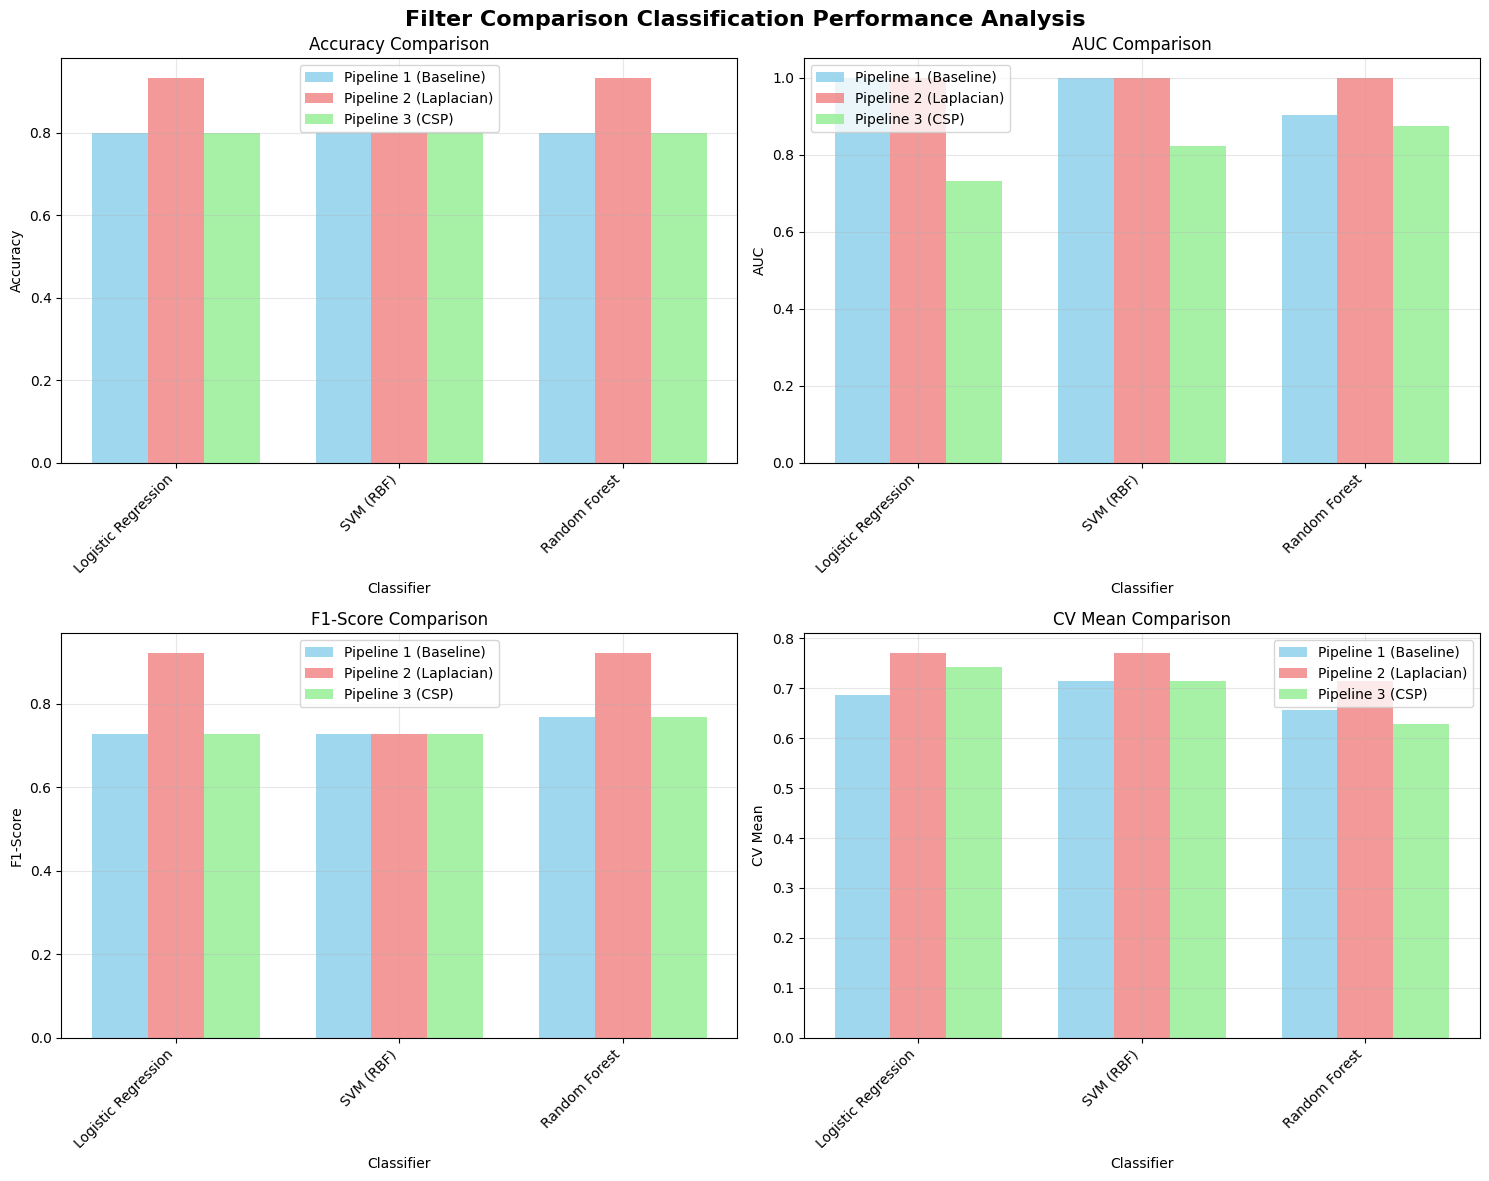

In [34]:
# Performance comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Filter Comparison Classification Performance Analysis', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'AUC', 'F1-Score', 'CV Mean']
colors = ['skyblue', 'lightcoral', 'lightgreen']
pipeline_order = ['Pipeline 1 (Baseline)', 'Pipeline 2 (Laplacian)', 'Pipeline 3 (CSP)']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Create grouped bar plot
    x_pos = np.arange(len(classifiers))
    width = 0.25
    
    for i, pipeline in enumerate(pipeline_order):
        pipeline_data = results_df[results_df['Pipeline'] == pipeline]
        values = pipeline_data[metric].values
        ax.bar(x_pos + i * width, values, width, label=pipeline, color=colors[i], alpha=0.8)
    
    ax.set_xlabel('Classifier')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(classifiers.keys(), rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('progressive_classification_performance.png', dpi=300, bbox_inches='tight')
plt.show()



=== FEATURE IMPORTANCE ANALYSIS (Random Forest) ===



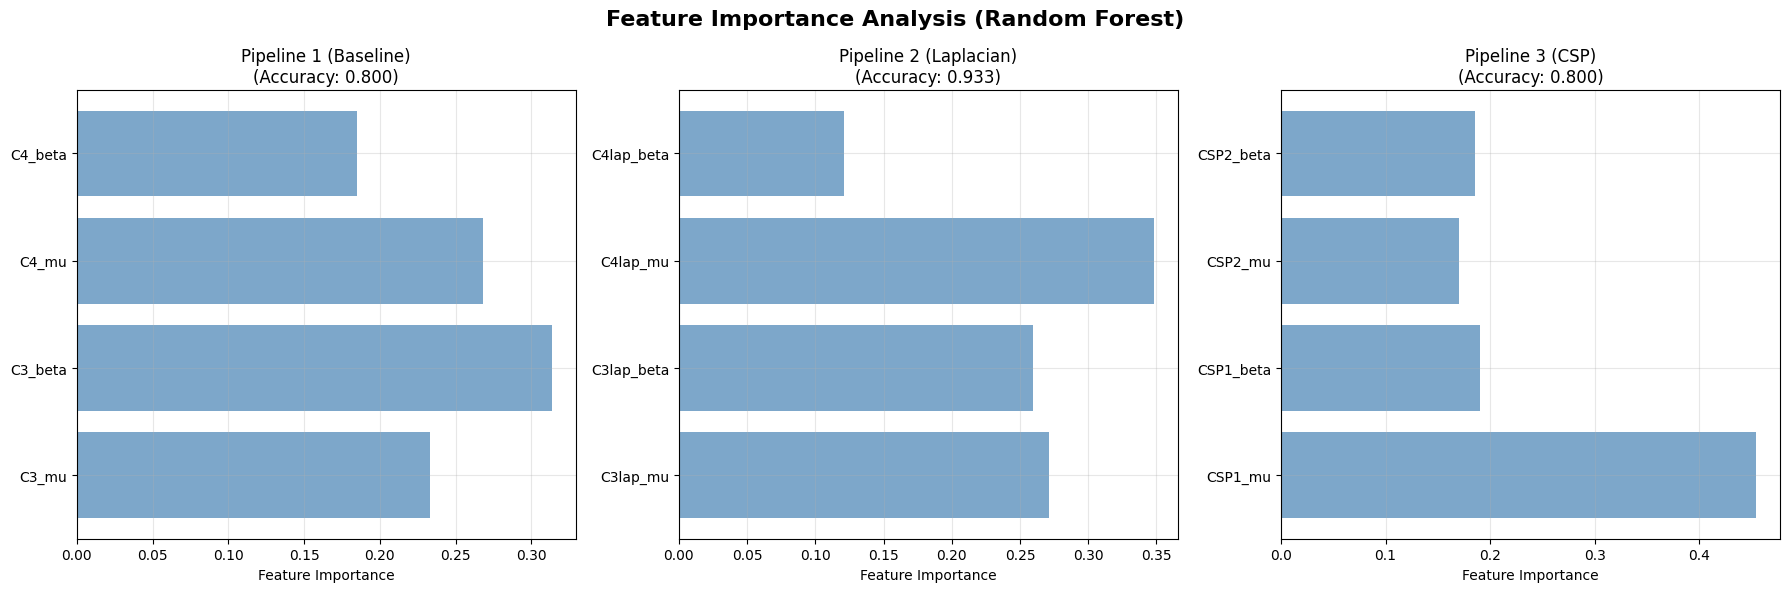

In [35]:
# Feature importance analysis (using Random Forest)
if 'Random Forest' in classifiers:
    print("\n=== FEATURE IMPORTANCE ANALYSIS (Random Forest) ===\n")
    
    # Feature names for each pipeline
    feature_names = {
        'Pipeline 1 (Baseline)': ['C3_mu', 'C3_beta', 'C4_mu', 'C4_beta'],
        'Pipeline 2 (Laplacian)': ['C3lap_mu', 'C3lap_beta', 'C4lap_mu', 'C4lap_beta'],
        'Pipeline 3 (CSP)': ['CSP1_mu', 'CSP1_beta', 'CSP2_mu', 'CSP2_beta']
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Feature Importance Analysis (Random Forest)', fontsize=16, fontweight='bold')
    
    for idx, pipeline in enumerate(pipeline_order):
        # Get Random Forest results for this pipeline
        rf_result = next(r for r in all_results if r['pipeline'] == pipeline and r['classifier'] == 'Random Forest')
        
        # Re-train Random Forest to get feature importances
        features = pipelines[pipeline]
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(features)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, labels, test_size=0.3, random_state=42, stratify=labels
        )
        
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        
        # Plot feature importances
        importances = rf.feature_importances_
        feature_labels = feature_names[pipeline]
        
        axes[idx].barh(range(len(importances)), importances, color='steelblue', alpha=0.7)
        axes[idx].set_yticks(range(len(importances)))
        axes[idx].set_yticklabels(feature_labels)
        axes[idx].set_xlabel('Feature Importance')
        axes[idx].set_title(f'{pipeline}\n(Accuracy: {rf_result["accuracy"]:.3f})')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('feature_importance_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


## Summary and Conclusions

Analyzing the effect of different spatial filters compared to baseline performance.


In [36]:
# Calculate improvement statistics
print("\n=== FILTER COMPARISON ANALYSIS ===\n")

improvement_stats = []

for classifier in classifiers.keys():
    clf_results = results_df[results_df['Classifier'] == classifier].copy()
    clf_results = clf_results.set_index('Pipeline').reindex(pipeline_order)
    
    baseline_acc = clf_results.loc['Pipeline 1 (Baseline)', 'Accuracy']
    laplacian_acc = clf_results.loc['Pipeline 2 (Laplacian)', 'Accuracy']
    csp_acc = clf_results.loc['Pipeline 3 (CSP)', 'Accuracy']
    
    baseline_auc = clf_results.loc['Pipeline 1 (Baseline)', 'AUC']
    laplacian_auc = clf_results.loc['Pipeline 2 (Laplacian)', 'AUC']
    csp_auc = clf_results.loc['Pipeline 3 (CSP)', 'AUC']
    
    # Calculate improvements
    laplacian_acc_improvement = ((laplacian_acc - baseline_acc) / baseline_acc) * 100
    csp_acc_improvement = ((csp_acc - baseline_acc) / baseline_acc) * 100
    
    laplacian_auc_improvement = ((laplacian_auc - baseline_auc) / baseline_auc) * 100
    csp_auc_improvement = ((csp_auc - baseline_auc) / baseline_auc) * 100
    
    improvement_stats.append({
        'Classifier': classifier,
        'Baseline_Acc': baseline_acc,
        'Laplacian_Acc': laplacian_acc,
        'CSP_Acc': csp_acc,
        'Laplacian_Acc_Improvement_%': laplacian_acc_improvement,
        'CSP_Acc_Improvement_%': csp_acc_improvement,
        'Baseline_AUC': baseline_auc,
        'Laplacian_AUC': laplacian_auc,
        'CSP_AUC': csp_auc,
        'Laplacian_AUC_Improvement_%': laplacian_auc_improvement,
        'CSP_AUC_Improvement_%': csp_auc_improvement
    })
    
    print(f"\n{classifier}:")
    print(f"  Accuracy: {baseline_acc:.3f} → {laplacian_acc:.3f} → {csp_acc:.3f}")
    print(f"  Laplacian improvement: {laplacian_acc_improvement:+.1f}%")
    print(f"  CSP improvement: {csp_acc_improvement:+.1f}%")
    print(f"  AUC: {baseline_auc:.3f} → {laplacian_auc:.3f} → {csp_auc:.3f}")
    print(f"  Laplacian AUC improvement: {laplacian_auc_improvement:+.1f}%")
    print(f"  CSP AUC improvement: {csp_auc_improvement:+.1f}%")

# Save improvement statistics
improvement_df = pd.DataFrame(improvement_stats)
improvement_df.to_csv('improvement_statistics.csv', index=False)
print("\nImprovement statistics saved to 'improvement_statistics.csv'")



=== FILTER COMPARISON ANALYSIS ===


Logistic Regression:
  Accuracy: 0.800 → 0.933 → 0.800
  Laplacian improvement: +16.7%
  CSP improvement: +0.0%
  AUC: 1.000 → 1.000 → 0.732
  Laplacian AUC improvement: +0.0%
  CSP AUC improvement: -26.8%

SVM (RBF):
  Accuracy: 0.800 → 0.800 → 0.800
  Laplacian improvement: +0.0%
  CSP improvement: +0.0%
  AUC: 1.000 → 1.000 → 0.821
  Laplacian AUC improvement: +0.0%
  CSP AUC improvement: -17.9%

Random Forest:
  Accuracy: 0.800 → 0.933 → 0.800
  Laplacian improvement: +16.7%
  CSP improvement: +0.0%
  AUC: 0.902 → 1.000 → 0.875
  Laplacian AUC improvement: +10.9%
  CSP AUC improvement: -3.0%

Improvement statistics saved to 'improvement_statistics.csv'
